<a href="https://colab.research.google.com/github/Mbokade2004/Mbokade2004/blob/main/Implementation_of_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - loss: 0.0971 - val_loss: 0.0198
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - loss: 0.0183 - val_loss: 0.0156
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.0148 - val_loss: 0.0135
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - loss: 0.0131 - val_loss: 0.0125
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - loss: 0.0121 - val_loss: 0.0115
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 0.0112 - val_loss: 0.0109
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - loss: 0.0107 - val_loss: 0.0104
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.0102 - val_loss: 0.0100
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - loss: 0.0098 - val_loss: 0.0097
Epoch 10/15
235/235 

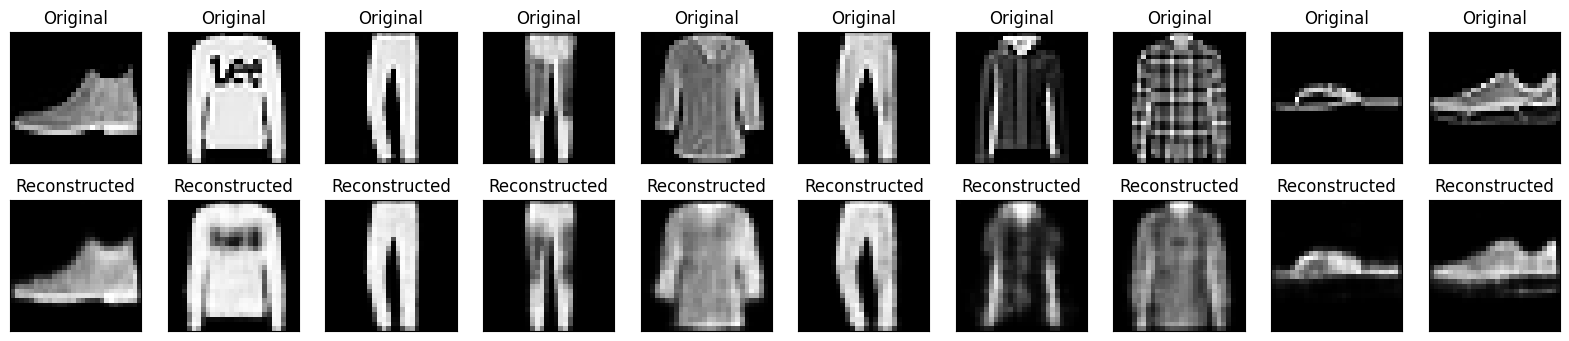

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
# Load the Fashion MNIST dataset
from tensorflow.keras.datasets import fashion_mnist
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the data to (batch_size, height, width, channels)
x_train = np.reshape(x_train, (x_train.shape[0], 28, 28, 1))
x_test = np.reshape(x_test, (x_test.shape[0], 28, 28, 1))

# Build the Autoencoder model
# Encoder
input_img = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', strides=2, padding='same')(input_img)
x = layers.Conv2D(16, (3, 3), activation='relu', strides=2, padding='same')(x)
encoded = layers.Flatten()(x)
latent = layers.Dense(128, activation='relu')(encoded)

# Decoder
x = layers.Dense(7 * 7 * 16, activation='relu')(latent)
x = layers.Reshape((7, 7, 16))(x)
x = layers.Conv2DTranspose(16, (3, 3), activation='relu', strides=2, padding='same')(x)
decoded = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', strides=2, padding='same')(x)

# Define the Autoencoder model
autoencoder = models.Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the Autoencoder
autoencoder.fit(x_train, x_train, epochs=15, batch_size=256, validation_data=(x_test, x_test))

# Evaluate and test the model
decoded_imgs = autoencoder.predict(x_test)

# Display the results: Original vs Reconstructed Images
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title("Original")

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title("Reconstructed")

plt.show()
